# SVD

Метод, позволяющий сжать данные. Потеряем слегка информации, но ускорим модель. Актуально только для разреженных матриц и когда не хватит места на полную матрицу. В остальных ситуациях PCA предпочтительнее

Для начала берём максимально возможно число компонент:  

In [10]:
import numpy as np
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [11]:
digits = load_digits()
X = digits.data
y = digits.target

print(f"Размер матрицы X: {X.shape}")
max_comp = min(X.shape)
print(f"Значит берём {max_comp} компоненты")

Размер матрицы X: (1797, 64)
Значит берём 64 компоненты


Иногда приходится применить маштабирование (или если конкретно, то только центрирование `with_mean=True`). Это связанно с тем, что `svd_full.explained_variance_ratio_` может вернуть неотсортированный список. Однако для разреженных матриц этот метод применить нельзя и придётся просто пробовать то что есть и делать выводы исходя из результатов ошибки модели

In [12]:
scaler = StandardScaler(with_std=False)
X = scaler.fit_transform(X)

Смотрим на визуализацию всех этих компонент

['567.01', '542.25', '504.63', '426.12', '353.34', '325.82', '305.26', '281.16', '269.07', '257.82', '226.32', '221.51', '198.33', '195.70', '177.98', '174.46', '168.73', '164.16', '148.23', '139.83', '138.58', '131.19', '128.73', '124.93', '122.58', '113.44', '111.48', '105.46', '102.81', '96.23', '89.81', '87.33', '85.26', '84.16', '81.59', '79.64', '74.43', '70.12', '69.28', '67.56', '64.03', '58.53', '57.13', '55.09', '50.18', '48.17', '45.62', '40.90', '34.69', '29.55', '21.29', '13.34', '10.65', '10.44', '8.44', '5.18', '3.90', '2.55', '1.51', '1.09', '0.86', '0.00', '0.00', '0.00']


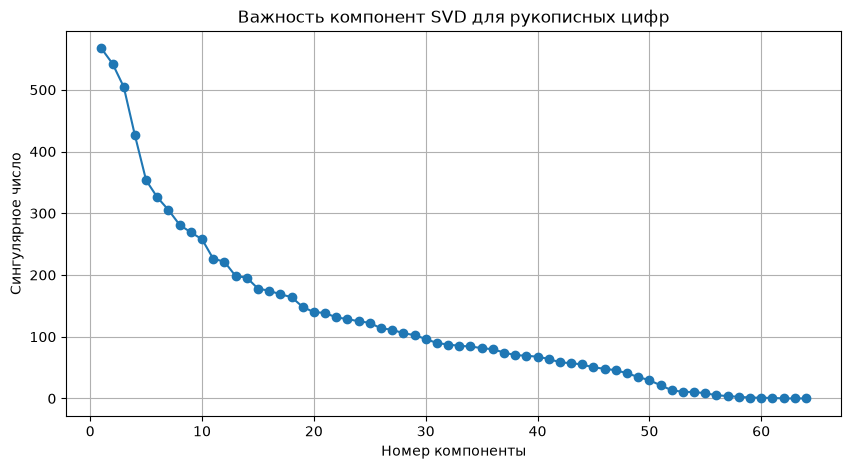

In [13]:
svd_full = TruncatedSVD(n_components=max_comp, random_state=42)
svd_full.fit(X)

# Сингулярные числа (важность каждой компоненты)
singular_vals = svd_full.singular_values_
print([f"{x:.2f}" for x in singular_vals])

# Визуализируем
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(singular_vals) + 1), singular_vals, 'o-')
plt.xlabel('Номер компоненты')
plt.ylabel('Сингулярное число')
plt.title('Важность компонент SVD для рукописных цифр')
plt.grid(True)
plt.show()

Мы можем так же это визуализировать через проценты (доли)

['14.89%', '13.62%', '11.79%', '8.41%', '5.78%', '4.92%', '4.32%', '3.66%', '3.35%', '3.08%', '2.37%', '2.27%', '1.82%', '1.77%', '1.47%', '1.41%', '1.32%', '1.25%', '1.02%', '0.91%', '0.89%', '0.80%', '0.77%', '0.72%', '0.70%', '0.60%', '0.58%', '0.52%', '0.49%', '0.43%', '0.37%', '0.35%', '0.34%', '0.33%', '0.31%', '0.29%', '0.26%', '0.23%', '0.22%', '0.21%', '0.19%', '0.16%', '0.15%', '0.14%', '0.12%', '0.11%', '0.10%', '0.08%', '0.06%', '0.04%', '0.02%', '0.01%', '0.01%', '0.01%', '0.00%', '0.00%', '0.00%', '0.00%', '0.00%', '0.00%', '0.00%', '0.00%', '0.00%', '0.00%']


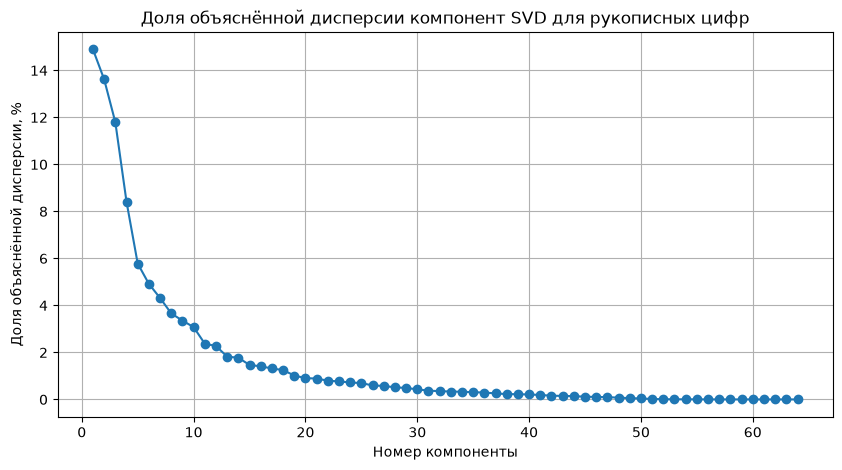

In [14]:
svd_full = TruncatedSVD(n_components=max_comp, random_state=42)
svd_full.fit(X)

# Доли объяснённой дисперсии для каждой компоненты
explained_ratios = svd_full.explained_variance_ratio_
print([f"{x*100:.2f}%" for x in explained_ratios])

# Визуализируем
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_ratios) + 1), explained_ratios * 100, 'o-')
plt.xlabel('Номер компоненты')
plt.ylabel('Доля объяснённой дисперсии, %')
plt.title('Доля объяснённой дисперсии компонент SVD для рукописных цифр')
plt.grid(True)
plt.show()

Используя накопленную сумму, можем увидеть в каком моменте нужно остановиться. Допустим если нам надо сохранить 95% информации, то:

['0.15', '0.29', '0.40', '0.49', '0.54', '0.59', '0.64', '0.67', '0.71', '0.74', '0.76', '0.78', '0.80', '0.82', '0.84', '0.85', '0.86', '0.88', '0.89', '0.89', '0.90', '0.91', '0.92', '0.93', '0.93', '0.94', '0.94', '0.95', '0.95', '0.96', '0.96', '0.97', '0.97', '0.97', '0.98', '0.98', '0.98', '0.98', '0.99', '0.99', '0.99', '0.99', '0.99', '0.99', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00', '1.00']


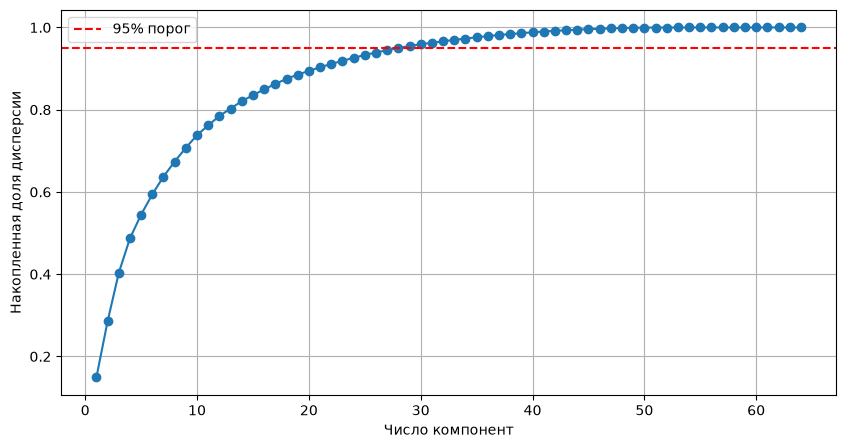

In [15]:
cumsum = np.cumsum(svd_full.explained_variance_ratio_)
print([f"{x:.2f}" for x in cumsum])

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cumsum) + 1), cumsum, 'o-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% порог')
plt.xlabel('Число компонент')
plt.ylabel('Накопленная доля дисперсии')
plt.grid(True)
plt.legend()
plt.show()

In [16]:
k = np.argmax(cumsum >= 0.95) + 1
print(f"Для сохранения 95% информации нужно {k} компонент.")

Для сохранения 95% информации нужно 29 компонент.


In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Обучаем SVD с выбранным k на тренировочных данных
svd = TruncatedSVD(n_components=k, random_state=42)
X_train_svd = svd.fit_transform(X_train)
X_test_svd = svd.transform(X_test)   # Внимание: только transform!

print(f"Размер до SVD: {X_train.shape}")
print(f"Размер после SVD: {X_train_svd.shape}")

# Обучаем логистическую регрессию на сжатых данных
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_svd, y_train)

# Оцениваем качество
y_pred = model.predict(X_test_svd)
acc = accuracy_score(y_test, y_pred)
print(f"Точность на тесте (с SVD, k={k}): {acc:.4f}")

# Для сравнения — обучим на исходных данных
model_full = LogisticRegression(max_iter=1000, random_state=42)
model_full.fit(X_train, y_train)
y_pred_full = model_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
print(f"Точность на тесте (без SVD): {acc_full:.4f}")

Размер до SVD: (1437, 64)
Размер после SVD: (1437, 29)
Точность на тесте (с SVD, k=29): 0.9556
Точность на тесте (без SVD): 0.9611


В данном случаи точность упала, однако в некоторых ситуациях точность наоборот может стать выше